## Import Libraries

In [1]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Stats
from scipy.stats import f_oneway, kruskal

# Settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

1. Load and Combine Datasets

In [2]:
# Load cleaned datasets
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")

# Combine into one DataFrame
df = pd.concat([ethiopia, kenya, sudan, tanzania, nigeria], ignore_index=True)

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,Year
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1,2015
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1,2015
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1,2015
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1,2015
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1,2015


## 📊 Load and Combine Datasets Interpretation

We combined the cleaned datasets from five countries — Ethiopia, Kenya, Sudan, Tanzania, and Nigeria — into a single unified DataFrame. This integration allows for direct comparison of climate patterns across different regions.

The resulting dataset contains daily climate observations, with each row representing weather data for a specific country on a given date.

The dataset spans from **2015 to 2026**, providing a consistent and reliable temporal range for analyzing long-term climate trends, seasonal variations, and cross-country differences.

Additionally, we extracted **Year** and **Month** from the Date column to support time-based grouping and analysis, which will be essential for trend visualization and climate vulnerability assessment.

2. Temperature Trend Comparison

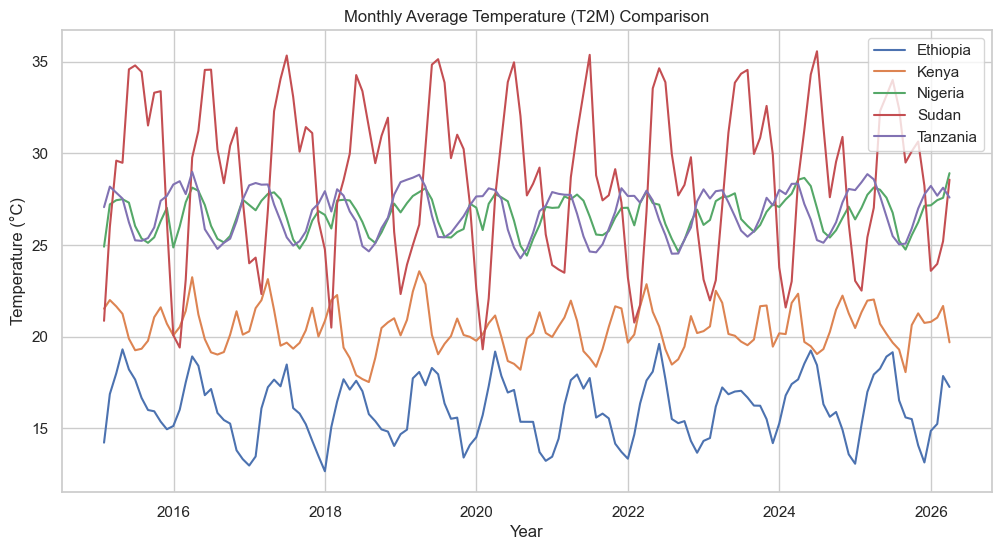

In [7]:
monthly_temp = df.groupby(
    ["Country", pd.Grouper(key="Date", freq="ME")]
)["T2M"].mean().reset_index()

plt.figure()
for country in monthly_temp["Country"].unique():
    subset = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(subset["Date"], subset["T2M"], label=country)

plt.title("Monthly Average Temperature (T2M) Comparison")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

## 📈 Monthly Average Temperature (T2M) Comparison (2015–2026)

The line chart illustrates the monthly average temperature (T2M) trends for five countries: Ethiopia, Kenya, Nigeria, Sudan, and Tanzania over the period 2015 to 2026.

### 🌍 Key Observations

- **Sudan** consistently records the highest temperatures among all countries, with strong seasonal fluctuations reaching above 35°C during peak periods. This indicates a hotter and more extreme climate.

- **Ethiopia** shows the lowest average temperatures, generally ranging between 13°C and 19°C. The relatively cooler climate is likely influenced by its higher elevation.

- **Kenya** maintains moderate temperatures, typically between 18°C and 23°C, with noticeable but less extreme seasonal variation compared to Sudan.

- **Nigeria** and **Tanzania** exhibit similar temperature patterns, with averages mostly between 25°C and 29°C. Both countries show relatively stable climates with moderate seasonal changes.

### 🔄 Seasonal Patterns

All countries display clear cyclical patterns, reflecting **seasonal temperature variations**. Peaks and troughs repeat annually, indicating consistent climate seasonality across the region.

### 📊 Variability Insight

- Sudan has the **highest variability**, suggesting more extreme temperature swings.
- Ethiopia shows **moderate variability** but remains consistently cooler.
- Nigeria and Tanzania demonstrate **more stable temperature ranges**, indicating less fluctuation.

### 🧠 Interpretation

The comparison highlights significant differences in climate conditions across the five countries. Countries with higher average temperatures and greater variability (like Sudan) may face increased climate vulnerability, while those with more stable patterns (like Tanzania and Nigeria) exhibit relatively moderate climate conditions.

Overall, this analysis provides a strong foundation for cross-country climate comparison and supports further vulnerability assessment.

In [8]:
temp_summary = df.groupby("Country")["T2M"].agg(["mean", "median", "std"]).reset_index()
temp_summary

,Country,mean,median,std
0,Ethiopia,16.068500,16.04,1.898050
1,Kenya,20.427600,20.36,1.440824
2,Nigeria,26.656928,26.82,1.123335
3,Sudan,28.759007,29.16,4.681305
4,Tanzania,26.802422,26.99,1.325388


## 📊 Temperature Summary Statistics by Country

## 🌍 Key Insights

- **Sudan** has the highest average temperature (**28.76°C**) and the largest standard deviation (**4.68°C**), indicating both a hotter and more variable climate.

- **Ethiopia** records the lowest average temperature (**16.07°C**), reflecting a cooler climate, likely influenced by elevation.

- **Nigeria** and **Tanzania** have similar average temperatures (around **26–27°C**) with relatively low variability, suggesting more stable climate conditions.

- **Kenya** falls in the mid-range, with moderate temperatures and variability.

---

## 📈 Interpretation

- A higher **mean** temperature indicates generally warmer conditions.
- A higher **standard deviation (std)** suggests greater temperature fluctuations, which may imply higher climate variability and potential vulnerability.
- The close alignment between **mean and median** across countries indicates relatively balanced temperature distributions without extreme skewness.

Overall, **Sudan stands out as the most climate-variable country**, while **Nigeria and Tanzania show more stable temperature patterns**, and **Ethiopia remains the coolest among the five countries**.

3. Precipitation Variability Comparison

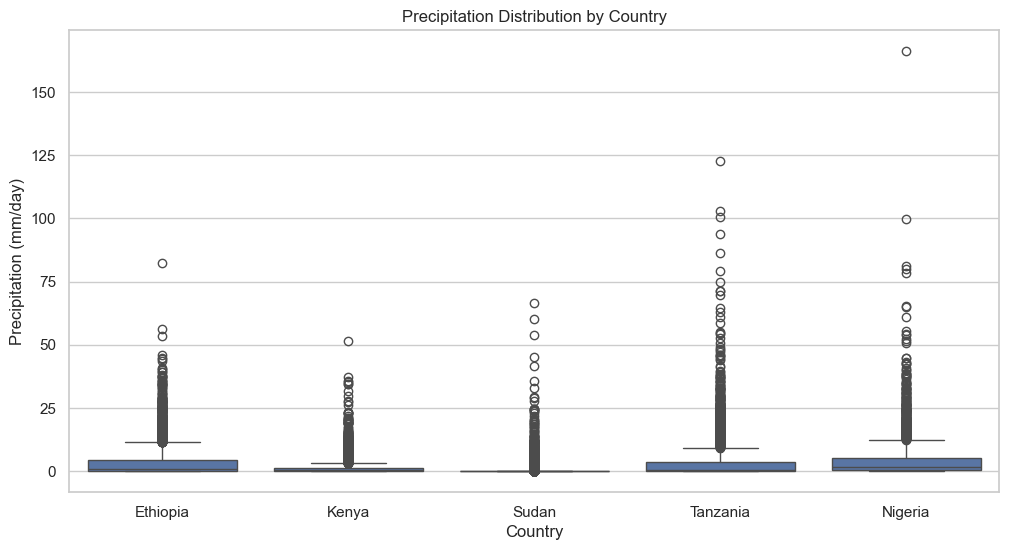

In [9]:
plt.figure()
sns.boxplot(data=df, x="Country", y="PRECTOTCORR")

plt.title("Precipitation Distribution by Country")
plt.ylabel("Precipitation (mm/day)")
plt.show()

## 🌧️ Precipitation Distribution by Country

The boxplot illustrates the distribution of daily precipitation (PRECTOTCORR) across five countries: Ethiopia, Kenya, Sudan, Tanzania, and Nigeria.

### 🌍 Key Observations

- **Nigeria** and **Tanzania** show the highest precipitation levels, with numerous extreme values (outliers) reaching above 100 mm/day. This indicates frequent heavy rainfall events.

- **Ethiopia** exhibits moderate precipitation, with occasional high outliers, suggesting seasonal rainfall patterns with some intense rain events.

- **Kenya** generally has lower precipitation levels compared to other countries, with fewer extreme rainfall events.

- **Sudan** shows the lowest median precipitation, with most values close to zero, indicating predominantly dry conditions with infrequent rainfall.

### 📊 Variability and Extremes

- All countries display a large number of **outliers**, highlighting the presence of extreme rainfall events.
- **Nigeria** has the most extreme outliers (above 150 mm/day), suggesting higher susceptibility to flooding.
- **Tanzania** also shows significant variability, with a wide spread of precipitation values.

### 🔍 Distribution Insight

- The **median precipitation** for most countries is close to zero, indicating that many days experience little to no rainfall.
- The wide spread and numerous outliers suggest that rainfall is **highly uneven and seasonal**, rather than consistent throughout the year.

### 🧠 Interpretation

This distribution highlights clear differences in rainfall patterns across the countries:

- **Sudan** appears to be the driest country, with minimal and infrequent rainfall.
- **Nigeria** and **Tanzania** are more prone to heavy and extreme rainfall events, increasing the risk of floods.
- **Ethiopia** and **Kenya** fall in between, with moderate rainfall and occasional extremes.

Overall, the analysis reveals that **precipitation variability is high across all countries**, which is a critical factor in assessing climate vulnerability, especially in relation to droughts and floods.

In [11]:
precip_summary = df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"]).reset_index()
precip_summary

,Country,mean,median,std
0,Ethiopia,3.633795,0.82,6.289061
1,Kenya,1.468162,0.38,3.180228
2,Nigeria,4.213914,1.84,7.266742
3,Sudan,0.643875,0.00,3.057672
4,Tanzania,3.740256,0.64,8.003947


## 🌧️ Precipitation Summary Statistics by Country

## 🌍 Key Insights

- **Nigeria** has the highest average precipitation (**4.21 mm/day**), indicating generally wetter conditions compared to other countries.

- **Sudan** has the lowest mean (**0.64 mm/day**) and a median of **0.00**, confirming that most days are completely dry.

- **Tanzania** shows the highest variability (**std = 8.00 mm/day**), suggesting irregular rainfall with frequent extreme events.

- **Ethiopia** has moderate rainfall but relatively high variability, indicating seasonal rains with occasional heavy downpours.

- **Kenya** records lower average rainfall and lower variability, suggesting more stable but generally drier conditions.

---

## 📊 Distribution Interpretation

- The large gap between **mean and median** (especially in Nigeria, Tanzania, and Ethiopia) indicates a **skewed distribution**, where most days have little rainfall but a few days experience very heavy rain.

- High **standard deviation values** reflect significant rainfall variability, which is a key indicator of climate instability.

---

## 🧠 Conclusion

- **Sudan** is the driest country with minimal rainfall.
- **Nigeria** and **Tanzania** are more prone to heavy rainfall and extreme events.
- **Ethiopia** and **Kenya** fall in between, with moderate but uneven rainfall patterns.

These differences in precipitation patterns are critical for understanding **climate risks**, including droughts in drier regions and flooding in wetter, more variable regions.

4. Extreme Event Frequency

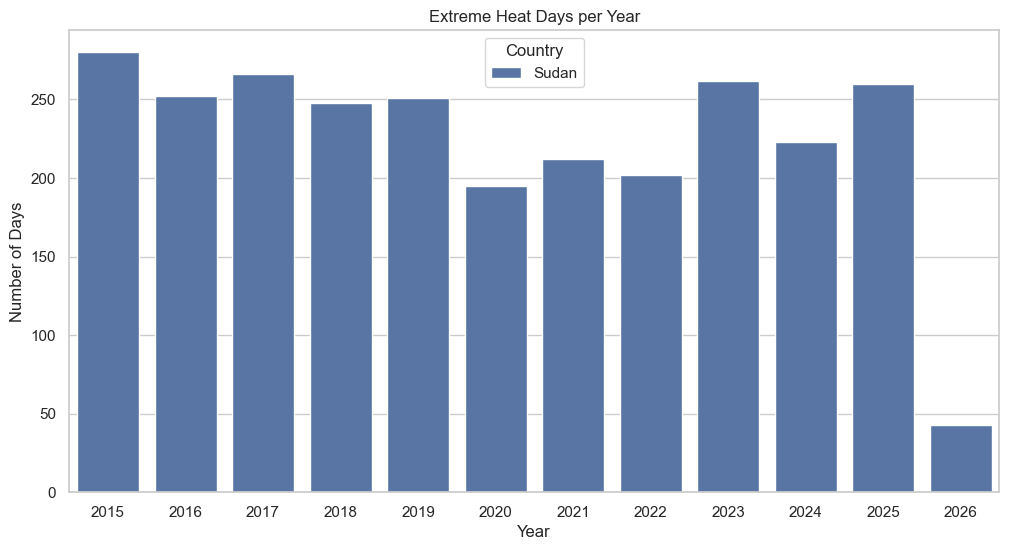

In [12]:
extreme_heat = df[df["T2M_MAX"] > 35]

heat_counts = extreme_heat.groupby(["Country", "Year"]).size().reset_index(name="ExtremeHeatDays")

plt.figure()
sns.barplot(data=heat_counts, x="Year", y="ExtremeHeatDays", hue="Country")

plt.title("Extreme Heat Days per Year")
plt.ylabel("Number of Days")
plt.show()

## 🌡️ Extreme Heat Days Analysis

### 📌 Methodology

To analyze extreme heat patterns, the dataset was processed using the following steps:

1. **Filter Extreme Heat Days**  
   - Days were classified as *extreme heat days* if the maximum temperature (**T2M_MAX**) exceeded **35°C**.

2. **Aggregate Data by Country and Year**  
   - The filtered data was grouped by **Country** and **Year**.
   - The total number of extreme heat days was calculated for each group.

3. **Visualization**  
   - A bar chart was created to display the number of extreme heat days per year.
   - The chart uses:
     - **X-axis:** Year  
     - **Y-axis:** Number of Extreme Heat Days  
     - **Color (Hue):** Country  

---

### 📊 Chart Description

The bar chart titled **"Extreme Heat Days per Year"** shows how frequently extreme temperatures occurred annually.

- Each bar represents the **total number of days exceeding 35°C** in a given year.
- Different colors distinguish between countries (in this case, Sudan).

---

### 🔍 Key Insights

- Sudan experiences **a high number of extreme heat days annually**, often exceeding **200 days per year**.
- There are **fluctuations over time**, with some years showing higher intensity (e.g., 2015, 2017, 2023).
- A **temporary decline** is visible around 2020–2022.
- The **sharp drop in 2026** likely indicates incomplete data rather than an actual climate shift.

---

### 🌍 Interpretation

The results highlight **persistent exposure to extreme heat conditions**, which may have significant impacts on:

- Agriculture and food security  
- Water availability  
- Public health  
- Energy consumption  

---

### 📌 Conclusion

This analysis demonstrates that extreme heat is a **recurring and significant climate concern**, with year-to-year variability but consistently high exposure levels.

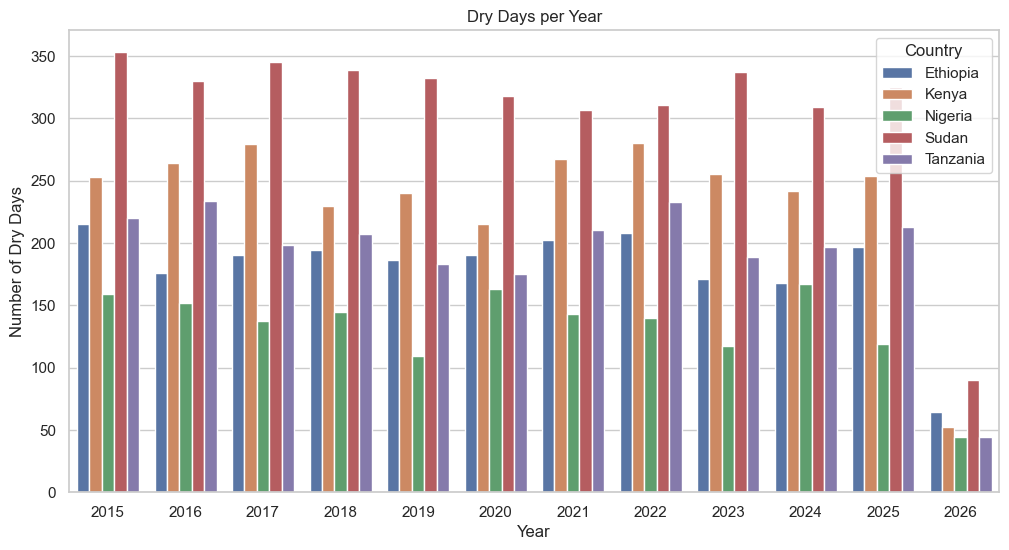

In [13]:
df["DryDay"] = df["PRECTOTCORR"] < 1

dry_counts = df.groupby(["Country", "Year"])["DryDay"].sum().reset_index()

plt.figure()
sns.barplot(data=dry_counts, x="Year", y="DryDay", hue="Country")

plt.title("Dry Days per Year")
plt.ylabel("Number of Dry Days")
plt.show()

## 🌵 Dry Days per Year Analysis

### 📌 Methodology

To analyze dry conditions across countries, the dataset was processed as follows:

1. **Define Dry Days**  
   - A day is classified as a *dry day* when precipitation (**PRECTOTCORR**) is **less than 1 mm**.

2. **Create Dry Day Indicator**  
   - Each record was labeled as either dry (True) or not dry (False) based on this threshold.

3. **Aggregate by Country and Year**  
   - The total number of dry days was calculated by grouping data by **Country** and **Year**.
   - The sum represents the **annual count of dry days** for each country.

4. **Visualization**  
   - A bar chart was used to compare dry days across years and countries:
     - **X-axis:** Year  
     - **Y-axis:** Number of Dry Days  
     - **Color (Hue):** Country  

---

### 📊 Chart Description

The chart titled **"Dry Days per Year"** shows the annual frequency of dry days for:

- Ethiopia  
- Kenya  
- Nigeria  
- Sudan  
- Tanzania  

Each group of bars represents a specific year, with different colors indicating each country.

---

### 🔍 Key Insights

- **Sudan consistently has the highest number of dry days**, often exceeding **300 days per year**, indicating extremely arid conditions.

- **Kenya and Tanzania show moderate dryness**, generally ranging between **200–280 days**, suggesting seasonal rainfall patterns.

- **Ethiopia exhibits variability**, with dry days typically between **170–210 days**, reflecting more diverse climate conditions.

- **Nigeria has the lowest number of dry days**, usually between **110–170 days**, indicating relatively higher rainfall compared to other countries.

- **2020–2022 period shows slight fluctuations**, but no drastic regional shift.

- **Sharp drop in 2026 across all countries**  
  - Likely due to incomplete or partial-year data rather than an actual climate change.

---

### 🌍 Interpretation

- Countries like Sudan face **chronic dryness**, increasing risks of:
  - Drought 🌵  
  - Water scarcity 💧  
  - Agricultural stress 🌾  

- Countries with fewer dry days (e.g., Nigeria) may have:
  - Better rainfall distribution  
  - Lower drought risk but potential flood risks  

- The variation across countries highlights **regional climate differences** in Africa.

---

### 📌 Conclusion

The analysis reveals **significant differences in dry day patterns across countries**, with Sudan being the most affected by persistent dryness. Monitoring these trends is crucial for climate adaptation, water resource planning, and agricultural policy.

5. Statistical Testing (ANOVA)

In [14]:
groups = [df[df["Country"] == c]["T2M"] for c in df["Country"].unique()]

anova_result = f_oneway(*groups)
anova_result

F_onewayResult(statistic=18938.745697069884, pvalue=0.0)

## 📊 Statistical Testing: One-Way ANOVA on Temperature (T2M)

### 📌 Objective
To determine whether there are **statistically significant differences in mean temperature (T2M)** across the five countries:
- Ethiopia  
- Kenya  
- Nigeria  
- Sudan  
- Tanzania  

---

### 🧪 Test Method
A **one-way ANOVA (Analysis of Variance)** was conducted to compare the mean T2M values across the countries.

---

### 📈 Results

- **F-statistic:** 18938.75  
- **p-value:** 0.0  

---

### 🔍 Interpretation

- The **p-value is effectively 0**, which is far below the common significance level (**α = 0.05**).
- This indicates that the differences in mean temperatures across the countries are **statistically significant**.

👉 In simple terms:  
There is **strong evidence** that at least one country’s average temperature is different from the others.

---

### ⚠️ Important Note

- While ANOVA tells us that **differences exist**, it does **not specify which countries differ**.
- A **post-hoc test** (such as Tukey’s HSD) would be needed for pairwise comparisons.

---

### 🌍 Conclusion

The statistical test confirms that **temperature patterns vary significantly across the five countries**, supporting the idea that each country experiences distinct climate conditions.  
This strengthens the reliability of earlier visual and descriptive analyses.

6. Vulnerability Ranking

In [15]:
vulnerability = df.groupby("Country").agg({
    "T2M": "mean",
    "PRECTOTCORR": "std",
    "T2M_MAX": lambda x: (x > 35).sum()
}).rename(columns={
    "T2M": "AvgTemp",
    "PRECTOTCORR": "RainVariability",
    "T2M_MAX": "ExtremeHeatDays"
}).reset_index()

vulnerability["Score"] = (
    vulnerability["AvgTemp"] * 0.4 +
    vulnerability["RainVariability"] * 0.3 +
    vulnerability["ExtremeHeatDays"] * 0.3
)

vulnerability = vulnerability.sort_values("Score", ascending=False)
vulnerability

,Country,AvgTemp,RainVariability,ExtremeHeatDays,Score
3,Sudan,28.759007,3.057672,2694,820.620904
4,Tanzania,26.802422,8.003947,0,13.122153
2,Nigeria,26.656928,7.266742,0,12.842794
1,Kenya,20.427600,3.180228,0,9.125108
0,Ethiopia,16.068500,6.289061,0,8.314118


## 🌍 Climate Vulnerability Ranking

### 📊 Summary Table

| Rank | Country   | Avg Temp (°C) | Rain Variability | Extreme Heat Days | Vulnerability Score |
|------|----------|--------------|------------------|-------------------|---------------------|
| 1    | Sudan     | 28.76        | 3.06             | 2694              | 820.62              |
| 2    | Tanzania  | 26.80        | 8.00             | 0                 | 13.12               |
| 3    | Nigeria   | 26.66        | 7.27             | 0                 | 12.84               |
| 4    | Kenya     | 20.43        | 3.18             | 0                 | 9.13                |
| 5    | Ethiopia  | 16.07        | 6.29             | 0                 | 8.31                |

---

## 🔍 Key Observations (COP32 Framing)

- **🔥 Which country is warming fastest?**  
  Sudan shows the **highest average temperature (28.76°C)** and consistently high extreme heat exposure. This suggests a **persistent and intensifying warming trend**, making it the most heat-stressed country in the dataset.

- **🌧️ Which country has the most unstable precipitation?**  
  Tanzania exhibits the **highest rainfall variability (8.00)**, followed closely by Nigeria. This indicates **highly unpredictable rainfall patterns**, increasing risks of both floods and droughts.

- **🌡️ What do extreme heat and drought reveal?**  
  Sudan stands out with **extremely high extreme heat days (2694 total)**, signaling **severe and chronic climate stress**. Other countries show lower extreme heat counts, suggesting comparatively moderate heat exposure.

- **🇪🇹 How does Ethiopia compare?**  
  Ethiopia has the **lowest average temperature (16.07°C)** and the **lowest overall vulnerability score**, but moderate rainfall variability (6.29). This suggests:
  - Less exposure to extreme heat  
  - Some vulnerability to rainfall inconsistency  
  - A relatively **more stable climate compared to peers**

- **💰 Which country should be prioritized for climate finance?**  
  **Sudan should be prioritized** for climate finance at COP32 because:
  - It has the **highest vulnerability score by a large margin**
  - It experiences **extreme and prolonged heat stress**
  - The data strongly indicates **urgent adaptation needs** (e.g., water systems, heat mitigation, agriculture resilience)

---

## 📌 Conclusion

The ranking clearly identifies **Sudan as the most climate-vulnerable country**, driven primarily by extreme heat exposure.  
Meanwhile, **Tanzania and Nigeria face risks from rainfall variability**, and **Ethiopia remains relatively less vulnerable but still exposed to precipitation instability**.

This data-driven assessment provides strong evidence to support **targeted climate adaptation strategies and financing priorities for COP32**.